In [1]:
import subprocess
import sys

def install_package(package):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"Successfully installed {package}")
    except Exception as e:
        print(f"Error installing {package}: {e}")

# This will install ultralytics safely even with the spaces in your path
install_package("ultralytics")

In [2]:
# Environment Setup

!pip install -q tensorflow==2.15 keras==2.15 opencv-python segmentation-models tensorflow-addons ultralytics

import os
import cv2
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

# Ensure TensorFlow backend
os.environ["KERAS_BACKEND"] = "tensorflow"

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0
Keras version: 3.13.2


In [3]:
# BOUNDING BOX UTILITIES

def get_bounding_box(mask):
    mask = (mask > 0.5).astype(np.uint8)

    # Remove small noise
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    # Largest contour
    c = max(contours, key=cv2.contourArea)

    x, y, w, h = cv2.boundingRect(c)

    return x, y, x+w, y+h


def draw_bounding_box(image, bbox):
    if bbox is None:
        return image

    x_min, y_min, x_max, y_max = bbox

    image_copy = image.copy()
    cv2.rectangle(image_copy, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)

    return image_copy

Total images: 2169
Total masks : 2169

Checking first 5 samples...

Sample: 0.png
Image shape: (224, 224, 3)
Mask shape : (512, 512)
Mask unique values: [ 30 215]
Tumor pixels: 262144
Tumor ratio: 1.0


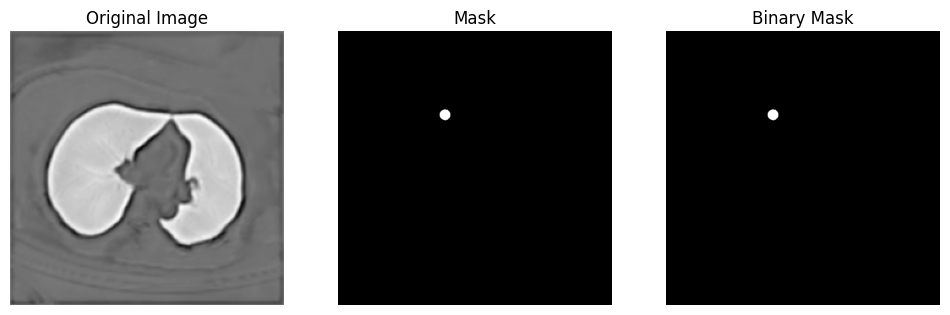

--------------------------------------------------
Sample: 1.png
Image shape: (224, 224, 3)
Mask shape : (512, 512)
Mask unique values: [ 30 215]
Tumor pixels: 262144
Tumor ratio: 1.0


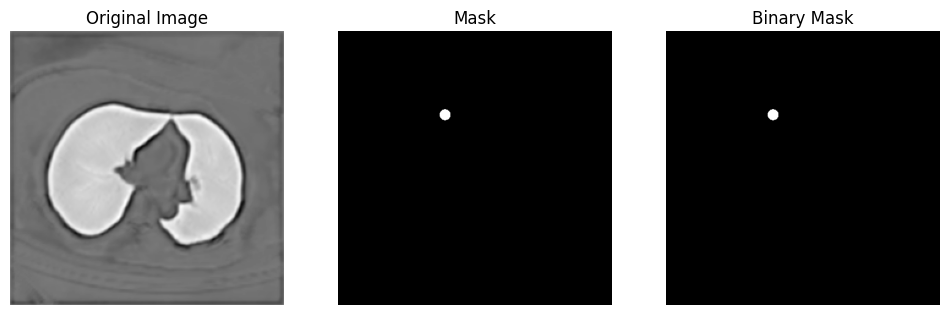

--------------------------------------------------
Sample: 10.png
Image shape: (224, 224, 3)
Mask shape : (512, 512)
Mask unique values: [ 30 215]
Tumor pixels: 262144
Tumor ratio: 1.0


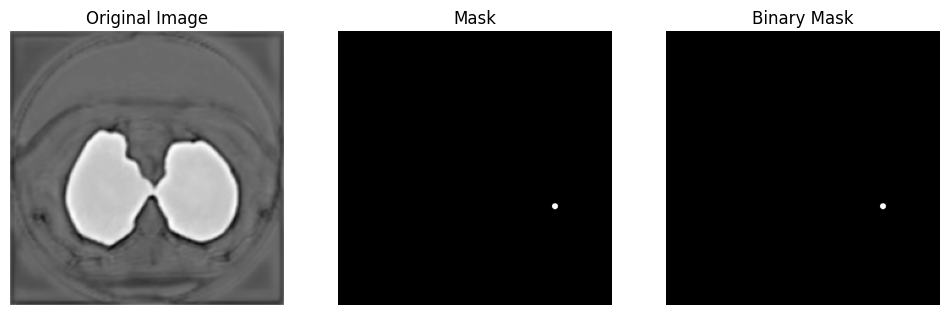

--------------------------------------------------
Sample: 100.png
Image shape: (224, 224, 3)
Mask shape : (512, 512)
Mask unique values: [ 30 215]
Tumor pixels: 262144
Tumor ratio: 1.0


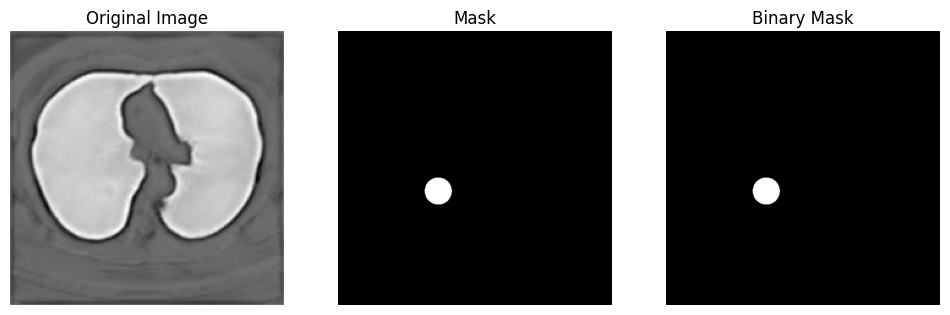

--------------------------------------------------
Sample: 1000.png
Image shape: (224, 224, 3)
Mask shape : (512, 512)
Mask unique values: [ 30 215]
Tumor pixels: 262144
Tumor ratio: 1.0


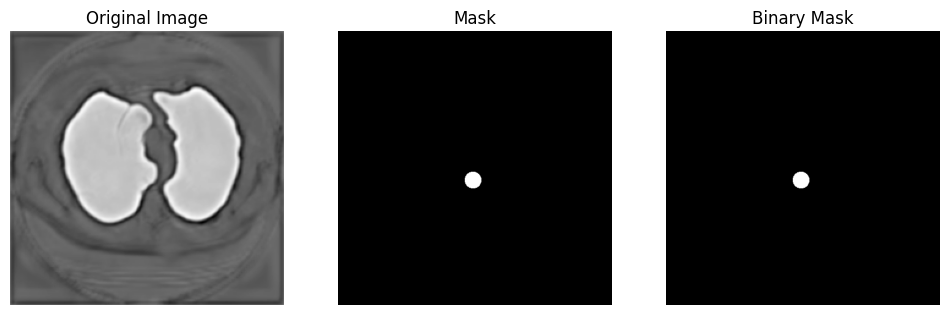

--------------------------------------------------


In [4]:
# DATASET DEBUGGING

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_DIR = r"C:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\Lung_segmentation\luna-classification-0\versions\3\lung_masks_positive"
MASK_DIR  = r"C:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\Lung_segmentation\luna-classification-0\versions\3\masks\masks"

image_files = sorted(os.listdir(IMAGE_DIR))
mask_files  = sorted(os.listdir(MASK_DIR))

print("Total images:", len(image_files))
print("Total masks :", len(mask_files))

assert len(image_files) == len(mask_files), "Image-mask count mismatch!"

print("\nChecking first 5 samples...\n")

for i in range(5):

    img_path = os.path.join(IMAGE_DIR, image_files[i])
    mask_path = os.path.join(MASK_DIR, mask_files[i])

    image = cv2.imread(img_path)
    mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    print("Sample:", image_files[i])
    print("Image shape:", image.shape)
    print("Mask shape :", mask.shape)

    unique_vals = np.unique(mask)
    print("Mask unique values:", unique_vals)

    tumor_pixels = np.sum(mask > 0)
    total_pixels = mask.size

    tumor_ratio = tumor_pixels / total_pixels

    print("Tumor pixels:", tumor_pixels)
    print("Tumor ratio:", tumor_ratio)

    # Convert mask to binary
    binary_mask = (mask > 100).astype(np.uint8)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Original Image")
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Mask")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Binary Mask")
    plt.imshow(binary_mask, cmap="gray")
    plt.axis("off")

    plt.show()

    print("--------------------------------------------------")

In [5]:
# DATASET LOADER FUNCTIONS

IMG_SIZE = 256
BATCH_SIZE = 8

def load_image_mask(img_path, mask_path, label):

    img_path = img_path.decode()
    mask_path = mask_path.decode() if mask_path is not None else None
    label = label.decode() if isinstance(label, bytes) else label

    # Read image
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Read mask
    if mask_path is not None:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 100).astype(np.float32)
    else:
        mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)

    # Resize image
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    # Resize mask (NEAREST keeps tumor pixels)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE),
                      interpolation=cv2.INTER_NEAREST)

    # Normalize image
    image = image / 255.0

    # Add mask channel
    mask = np.expand_dims(mask, axis=-1)

    return image.astype(np.float32), mask.astype(np.float32), np.float32(label)


def tf_loader(img_path, mask_path, label):

    image, mask, label = tf.numpy_function(
        load_image_mask,
        [img_path, mask_path, label],
        [tf.float32, tf.float32, tf.float32]
    )

    image.set_shape([IMG_SIZE, IMG_SIZE, 3])
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1])
    label.set_shape([])

    return image, {"segmentation": mask, "classification": label}


print("Dataset loader ready.")

Dataset loader ready.


In [6]:
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split

# --- CONFIGURATION ---
IMAGE_DIR_POS = r"C:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\Lung_segmentation\luna-classification-0\versions\3\lung_masks_positive"
MASK_DIR = r"C:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\Lung_segmentation\luna-classification-0\versions\3\masks\masks"
IMAGE_DIR_NEG = r"C:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\Lung_segmentation\luna-classification-0\versions\3\lung_masks_negatives"
IMG_SIZE = (224, 224) # Set this to your required input size

def load_image_mask(img_path, mask_path, label):
    """
    Loads image and mask from paths. 
    If mask_path is None (negative case), creates a blank mask.
    """
    # 1. Load Image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img / 255.0  # Normalize
    
    # 2. Load or Create Mask
    if mask_path is not None:
        msk = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        msk = cv2.resize(msk, IMG_SIZE)
        msk = msk / 255.0  # Normalize to 0-1
    else:
        # Create a blank (black) mask for negative samples
        msk = np.zeros((IMG_SIZE[0], IMG_SIZE[1]), dtype=np.float32)
        
    # Expand dims of mask to (H, W, 1) if needed for the model
    msk = np.expand_dims(msk, axis=-1)
        
    return img, msk, label

def load_dataset_as_numpy(img_paths, mask_paths, labels):
    images = []
    masks = []
    cls_labels = []
    
    for img_p, msk_p, lbl in zip(img_paths, mask_paths, labels):
        img, msk, label = load_image_mask(img_p, msk_p, lbl)
        images.append(img)
        masks.append(msk)
        cls_labels.append(label)
    
    return np.array(images), np.array(masks), np.array(cls_labels)

# --- FILE PREPARATION ---
image_files_pos = sorted(os.listdir(IMAGE_DIR_POS))
mask_files_pos = sorted(os.listdir(MASK_DIR))
image_files_neg = sorted(os.listdir(IMAGE_DIR_NEG))

# Create full paths
pos_img_paths = [os.path.join(IMAGE_DIR_POS, f) for f in image_files_pos]
pos_mask_paths = [os.path.join(MASK_DIR, f) for f in mask_files_pos]
neg_img_paths = [os.path.join(IMAGE_DIR_NEG, f) for f in image_files_neg]
neg_mask_paths = [None] * len(neg_img_paths) # Placeholder for negatives

# Combine
image_paths = pos_img_paths + neg_img_paths
mask_paths = pos_mask_paths + neg_mask_paths
labels = ([1.0] * len(pos_img_paths)) + ([0.0] * len(neg_img_paths))

# --- SPLIT ---
train_imgs, val_imgs, train_masks, val_masks, train_labels, val_labels = train_test_split(
    image_paths,
    mask_paths,
    labels,
    test_size=0.15,
    random_state=42
)

# --- EXECUTION ---
print(f"Loading {len(train_imgs)} training samples...")
train_images, train_masks, train_cls_labels = load_dataset_as_numpy(train_imgs, train_masks, train_labels)

print(f"Loading {len(val_imgs)} validation samples...")
val_images, val_masks, val_cls_labels = load_dataset_as_numpy(val_imgs, val_masks, val_labels)

print("---")
print("Data loading complete.")
print("Images shape:", train_images.shape)
print("Masks shape:", train_masks.shape)
print("Labels shape:", train_cls_labels.shape)

Loading 4726 training samples...
Loading 834 validation samples...
---
Data loading complete.
Images shape: (4726, 224, 224, 3)
Masks shape: (4726, 224, 224, 1)
Labels shape: (4726,)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB4
from ultralytics import YOLO

# --- ATTENTION GATE ---
def attention_gate(x, g, filters):
    # Gating signal (from deeper layer)
    g_conv = layers.Conv2D(filters, 1, padding="same")(g)
    # Skip connection signal
    x_conv = layers.Conv2D(filters, 1, padding="same")(x)
    
    # Resize x to match g's spatial dimensions
    x_res = layers.Resizing(g.shape[1], g.shape[2])(x_conv)

    combined = layers.Add()([x_res, g_conv])
    activated = layers.Activation("relu")(combined)

    # Calculate attention coefficients
    psi = layers.Conv2D(1, 1, padding="same")(activated)
    psi = layers.Activation("sigmoid")(psi)

    return layers.Multiply()([x_res, psi])

def decoder_block(x, skip, filters):
    x = layers.UpSampling2D((2, 2))(x)
    skip = attention_gate(skip, x, filters)
    x = layers.Concatenate()([x, skip])
    
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    return x

def build_large_hybrid_model(img_size=224):
    inputs = layers.Input((img_size, img_size, 3), name="input_layer")

    # EFFICIENTNET B4
    encoder = EfficientNetB4(
        include_top=False, 
        weights="imagenet", 
        input_tensor=inputs
    )

    # 2. EXTRACT SKIP CONNECTIONS
    s1 = encoder.get_layer("block2a_activation").output  # High Res
    s2 = encoder.get_layer("block3a_activation").output
    s3 = encoder.get_layer("block4a_activation").output
    s4 = encoder.get_layer("block6a_activation").output  # Low Res
    bridge = encoder.get_layer("top_activation").output # Bottleneck

    # 3. DECODER WITH ATTENTION
    d1 = decoder_block(bridge, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    # Final Upsampling to match 224x224
    d5 = layers.UpSampling2D((2, 2))(d4)
    d5 = layers.Conv2D(32, 3, padding="same", activation="relu")(d5)
    
    # SEGMENTATION HEAD
    seg_output = layers.Conv2D(1, 1, activation="sigmoid", name="segmentation")(d5)

    # CLASSIFICATION HEAD
    gap = layers.GlobalAveragePooling2D()(bridge)
    cls_output = layers.Dense(1, activation="sigmoid", name="classification")(gap)

    return models.Model(inputs, [seg_output, cls_output])

model = build_large_hybrid_model(img_size=224)

yolo_model = YOLO('yolov8n.pt') 

print("Architecture Defined: EfficientNetB4 Attention U-Net + YOLOv8")
model.summary()

Architecture Defined: EfficientNetB4 Attention U-Net + YOLOv8


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      1,152 │ block1a_se_excit

 Total params: 35,480,165 (135.35 MB)

 Trainable params: 35,351,118 (134.85 MB)

 Non-trainable params: 129,047 (504.09 KB)

In [9]:
from tensorflow.keras import backend as K
import tensorflow as tf

# Dice Coefficient: Measures overlap (0 to 1)
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# IoU Score: Intersection over Union
def iou_score(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# Hybrid Loss: Binary Cross-Entropy + Dice Loss
def bce_dice_loss(y_true, y_pred):
    # Ensure y_true and y_pred are cast to float32
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + (1 - dice_coef(y_true, y_pred))

print("Metrics and Loss functions defined successfully.")

Metrics and Loss functions defined successfully.


In [ ]:
# UPDATE THIS CELL
def focal_loss(gamma=2., alpha=.25):
    def focal_loss_fixed(y_true, y_pred):
        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
        return -tf.reduce_sum(alpha * tf.pow(1. - pt_1, gamma) * tf.math.log(pt_1 + 1e-7)) \
               -tf.reduce_sum((1 - alpha) * tf.pow(pt_0, gamma) * tf.math.log(1. - pt_0 + 1e-7))
    return focal_loss_fixed

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        'segmentation': bce_dice_loss, 
        'classification': focal_loss() 
    },
    metrics={
        'segmentation': [dice_coef, iou_score], 
        'classification': 'accuracy'
    }
)

In [ ]:
import numpy as np
import tensorflow as tf

y_labels = np.array([1.0 if np.max(m) > 0.5 else 0.0 for m in train_masks], dtype="float32").reshape(-1, 1)
y_val_labels = np.array([1.0 if np.max(m) > 0.5 else 0.0 for m in val_masks], dtype="float32").reshape(-1, 1)

def focal_loss(gamma=2., alpha=.25):
    def focal_loss_fixed(y_true, y_pred):
        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
        return -tf.reduce_sum(alpha * tf.pow(1. - pt_1, gamma) * tf.math.log(pt_1 + 1e-7)) \
               -tf.reduce_sum((1 - alpha) * tf.pow(pt_0, gamma) * tf.math.log(1. - pt_0 + 1e-7))
    return focal_loss_fixed

optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4) 

model.compile(
    optimizer=optimizer,
    loss={
        "segmentation": bce_dice_loss, 
        "classification": focal_loss() 
    },
    # classification weight higher to address the 506 Normal vs 328 Malignant imbalance.
    loss_weights={"segmentation": 1.0, "classification": 3.0}, 
    metrics={"segmentation": [dice_coef, iou_score], "classification": ["accuracy"]}
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_lung_model_v2.keras", 
        monitor="val_classification_accuracy", 
        mode="max", 
        save_best_only=True,
        verbose=1 
    ),
    tf.keras.callbacks.CSVLogger("training_log_v2.csv", append=True),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
]

history = model.fit(
    train_images,
    {"segmentation": train_masks, "classification": y_labels},
    validation_data=(val_images, {"segmentation": val_masks, "classification": y_val_labels}),
    epochs=25,
    batch_size=4, 
    callbacks=callbacks,
    verbose=1
)

print("\n--- Training finished ---")

Epoch 1/25
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - classification_accuracy: 0.6291 - classification_loss: 0.2730 - loss: 1.9661 - segmentation_dice_coef: 0.0584 - segmentation_iou_score: 0.0303 - segmentation_loss: 1.1471
Epoch 1: val_classification_accuracy improved from None to 0.60671, saving model to best_lung_model_v2.keras

Epoch 1: finished saving model to best_lung_model_v2.keras
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 6292s 5s/step - classification_accuracy: 0.6322 - classification_loss: 0.2514 - loss: 1.8865 - segmentation_dice_coef: 0.0600 - segmentation_iou_score: 0.0312 - segmentation_loss: 1.1322 - val_classification_accuracy: 0.6067 - val_classification_loss: 0.2912 - val_loss: 2.1054 - val_segmentation_dice_coef: 0.0393 - val_segmentation_iou_score: 0.0203 - val_segmentation_loss: 1.2297 - learning_rate: 2.0000e-04
Epoch 2/25
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - classification_accuracy: 0.6435 - classification_loss: 0.2273 - loss: 1.8055 - segmentation_dice_coef: 0.06

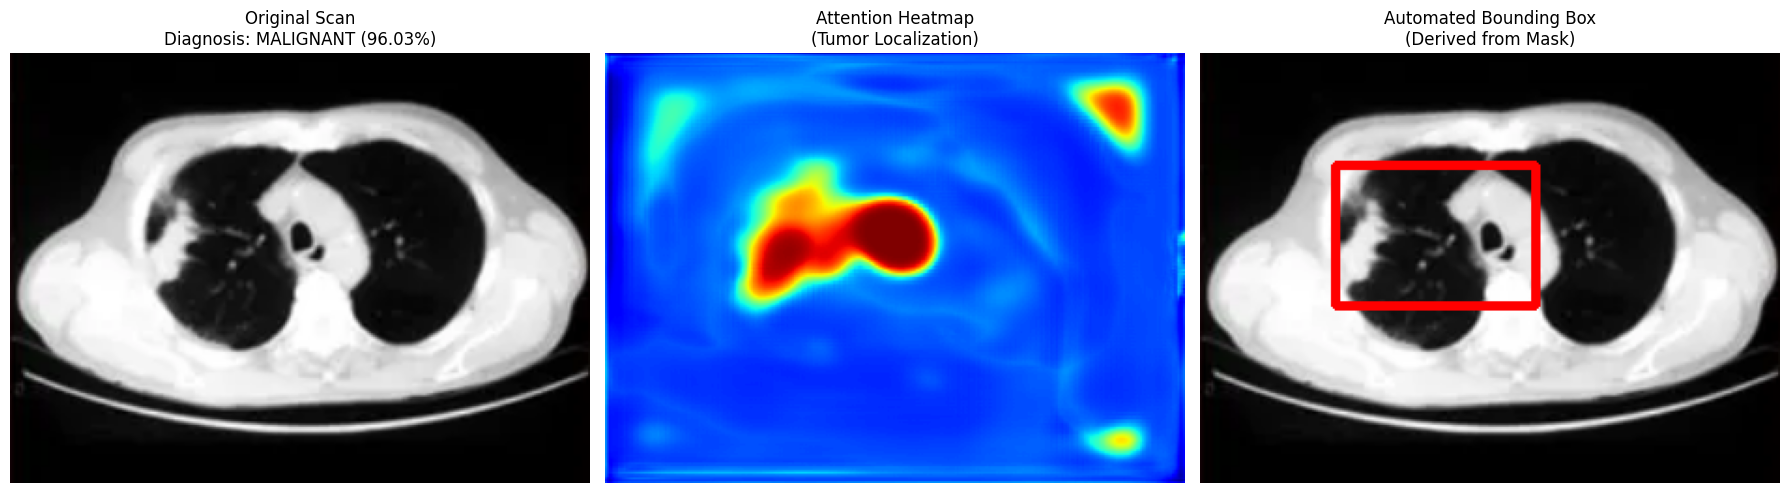

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

def predict_tumor(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    target_size = (224, 224) 

    img_resized = cv2.resize(img_rgb, target_size) 
    img_input = np.expand_dims(img_resized / 255.0, axis=0)

    try:
        outputs = model.predict(img_input, verbose=0)
        if isinstance(outputs, list):
            raw_mask = outputs[0][0]
            confidence = outputs[1][0][0]
        else:
            raw_mask = outputs[0]
            confidence = 0.5 
            
        h, w, _ = img.shape
        mask_resized = cv2.resize(raw_mask, (w, h))
        return mask_resized, confidence

    except Exception as e:
        print(f"Dimension Mismatch still occurring: {e}")
        print("Try changing target_size to 256, 380, or 512.")
        return None, 0

def visualize_final_output(image_path):
    mask, confidence = predict_tumor(image_path)
    
    # Threshold the mask for the Bounding Box calculation
    binary_mask = (mask > 0.5).astype(np.uint8)
    
    original = cv2.imread(image_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    
    # Calculate Bounding Box from Mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxed_img = original.copy()
    if contours:
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)
        cv2.rectangle(boxed_img, (x, y), (x+w, y+h), (255, 0, 0), 3) # Red Box

    # PLOTTING
    plt.figure(figsize=(18, 6))
    
    # Raw Image + Classification
    plt.subplot(1, 3, 1)
    plt.imshow(original)
    status = "MALIGNANT" if confidence > 0.5 else "NORMAL"
    plt.title(f"Original Scan\nDiagnosis: {status} ({confidence:.2%})")
    plt.axis("off")
    
    # Attention U-Net Segmentation
    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='jet')
    plt.title("Attention Heatmap\n(Tumor Localization)")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(boxed_img)
    plt.title("Automated Bounding Box\n(Derived from Mask)")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

target_path = r"C:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\p.png"
visualize_final_output(target_path)

🔍 Analyzing: C:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\p.png


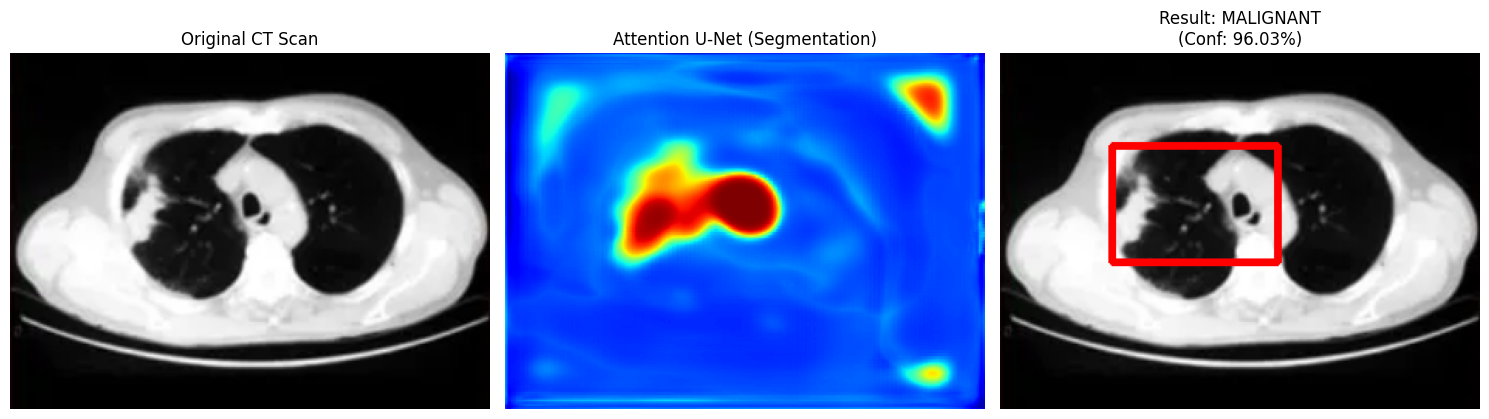

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

def predict_tumor(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not find image at {image_path}")
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    target_size = (224, 224) 
    img_resized = cv2.resize(img_rgb, target_size)
    img_input = np.expand_dims(img_resized / 255.0, axis=0) # Normalize to [0,1]

    outputs = model.predict(img_input, verbose=0)
    
    raw_mask = outputs[0][0]      # Extract the mask from batch
    confidence = outputs[1][0][0] # Extract classification probability
    
    # Scale Mask back to original image size for visualization
    h, w, _ = img.shape
    mask_resized = cv2.resize(raw_mask, (w, h))
    
    if len(mask_resized.shape) == 3:
        mask_resized = mask_resized.squeeze()
        
    return mask_resized, confidence

def get_bounding_box(mask):
    # Threshold to create binary mask
    binary_mask = (mask > 0.5).astype(np.uint8)
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) > 0:
        largest = max(contours, key=cv2.contourArea)
        return cv2.boundingRect(largest) # returns (x, y, w, h)
    return None

def draw_bounding_box(image, bbox):
    copy = image.copy()
    if bbox is not None:
        x, y, w, h = bbox
        cv2.rectangle(copy, (x, y), (x+w, y+h), (255, 0, 0), 3) 
    return copy

def test_single_image(img_path):
    print(f"Analyzing: {img_path.split('/')[-1]}")
    
    # Load original
    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Run Prediction
    try:
        mask, confidence = predict_tumor(img_path)
    except Exception as e:
        print(f"❌ Prediction Error: {e}")
        return

    # Process Box
    bbox = get_bounding_box(mask)
    boxed_image = draw_bounding_box(image_rgb, bbox)

    # Display Results
    plt.figure(figsize=(15, 5))
    
    # Original
    plt.subplot(1, 3, 1)
    plt.title("Original CT Scan")
    plt.imshow(image_rgb)
    plt.axis("off")

    # Mask
    plt.subplot(1, 3, 2)
    plt.title("Attention U-Net (Segmentation)")
    plt.imshow(mask, cmap="jet") 
    plt.axis("off")

    # Detection
    plt.subplot(1, 3, 3)
    diag = "MALIGNANT" if confidence > 0.5 else "NORMAL"
    plt.title(f"Result: {diag}\n(Conf: {confidence:.2%})")
    plt.imshow(boxed_image)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

target_path = r"C:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\p.png"
test_single_image(target_path)

In [ ]:
import numpy as np
import cv2
import pandas as pd

# 1. THE ANALYTICS FUNCTION
def tumor_analytics(mask):
    mask = (mask > 0.5).astype(np.uint8)
    if len(mask.shape) == 3:
        mask = mask.squeeze()

    tumor_pixels = np.sum(mask)
    total_pixels = mask.shape[0] * mask.shape[1]
    tumor_coverage = (tumor_pixels / total_pixels) * 100

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    diameter = 0
    
    if len(contours) > 0:
        largest = max(contours, key=cv2.contourArea)
        (x, y), radius = cv2.minEnclosingCircle(largest)
        diameter = radius * 2

    severity = "Normal/Insignificant"
    if 0.1 < tumor_coverage <= 2.0:
        severity = "Early Stage / Small Lesion"
    elif tumor_coverage > 2.0:
        severity = "Significant Growth / Advanced"

    return {
        "Total Tumor Pixels": int(tumor_pixels),
        "Lung Coverage %": round(float(tumor_coverage), 4),
        "Bounding Diameter (px)": round(float(diameter), 2),
        "Diagnostic Hint": severity
    }

# 2. THE SEVERITY SCORING FUNCTION
def compute_severity_score(classifier_confidence, analytics):
    diameter = analytics["Bounding Diameter (px)"]
    coverage = analytics["Lung Coverage %"]

    diameter_score = min(diameter / 50.0, 1.0)
    coverage_score = min(coverage / 10.0, 1.0)

    severity = (0.5 * classifier_confidence + 0.3 * diameter_score + 0.2 * coverage_score)
    severity_score = int(severity * 100)

    if severity_score >= 75: risk = "CRITICAL / HIGH"
    elif severity_score >= 40: risk = "MODERATE / MEDIUM"
    else: risk = "STABLE / LOW"

    return severity_score, risk

# --- EXECUTION ---
image_path = r"C:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\p.png"

# prediction
mask, confidence = predict_tumor(image_path)

# Analytics & Scores
stats = tumor_analytics(mask)
score, risk_level = compute_severity_score(confidence, stats)

# filename
filename = image_path.split('\\')[-1]

# Report Output
print("-" * 40)
print(f"ANALYTICS REPORT: {filename}")
print("-" * 40)

for key, value in stats.items():
    print(f"{key:<25}: {value}")

print("-" * 40)
print(f"AI Classification Confidence : {confidence:.2%}")
print(f"Calculated Severity Score    : {score}/100")
print(f"Final Risk Assessment        : {risk_level}")
print("-" * 40)

----------------------------------------
ANALYTICS REPORT: p.png
----------------------------------------
Total Tumor Pixels       : 5760
Lung Coverage %          : 8.0785
Bounding Diameter (px)   : 110.37
Diagnostic Hint          : Significant Growth / Advanced
----------------------------------------
AI Classification Confidence : 96.03%
Calculated Severity Score    : 94/100
Final Risk Assessment        : CRITICAL / HIGH
----------------------------------------


In [37]:
import numpy as np

def compute_severity_score(classifier_confidence, analytics):
    # Extracts keys from the tumor_analytics function output
    diameter = analytics["Bounding Diameter (px)"]
    coverage = analytics["Lung Coverage %"]

    # Normalize tumor diameter (assumes 50px is a large lesion)
    diameter_score = min(diameter / 50.0, 1.0)

    # Normalize tumor coverage (assumes 10% lung coverage is critical)
    coverage_score = min(coverage / 10.0, 1.0)

    # Weighted Calculation: 50% Confidence, 30% Diameter, 20% Coverage
    severity = (
        0.5 * classifier_confidence +
        0.3 * diameter_score +
        0.2 * coverage_score
    )

    severity_score = int(severity * 100)

    # Risk Categorization
    if severity_score >= 75:
        risk = "CRITICAL / HIGH"
    elif severity_score >= 40:
        risk = "MODERATE / MEDIUM"
    else:
        risk = "STABLE / LOW"

    return severity_score, risk

# --- 2. EXECUTION & DISPLAY ---
# Ensure 'mask' and 'confidence' exist from your previous cell
try:
    # Generate the analytics first
    analytics_data = tumor_analytics(mask)
    
    # Calculate severity
    score, risk_level = compute_severity_score(confidence, analytics_data)

    # Display Results
    print("="*40)
    print("      LUNG CANCER DIAGNOSTIC REPORT      ")
    print("="*40)
    print(f"Classification Score : {confidence:.2%}")
    print(f"Tumor Diameter       : {analytics_data['Bounding Diameter (px)']} px")
    print(f"Lung Coverage        : {analytics_data['Lung Coverage %']}%")
    print("-" * 40)
    print(f"FINAL SEVERITY SCORE : {score}/100")
    print(f"CLINICAL RISK LEVEL  : {risk_level}")
    print("="*40)

except NameError:
    print("Error: Ensure you run the prediction cell first to define 'mask' and 'confidence'.")

      LUNG CANCER DIAGNOSTIC REPORT      
Classification Score : 96.03%
Tumor Diameter       : 110.37 px
Lung Coverage        : 8.0785%
----------------------------------------
FINAL SEVERITY SCORE : 94/100
CLINICAL RISK LEVEL  : CRITICAL / HIGH


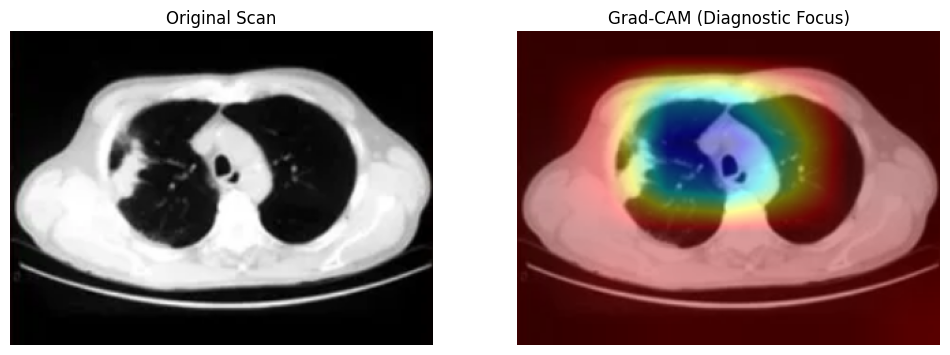

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def generate_gradcam(model, image, layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(layer_name).output,
            model.get_layer("classification").output 
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        loss = predictions[:, 0] 

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap for visualization
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def overlay_gradcam(image, heatmap):
    heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    
    overlay = cv2.addWeighted(image, 0.6, heatmap_color, 0.4, 0)
    return overlay

try:
    # Preprocess image same as prediction
    target_path = r"C:\Users\Bilal\OneDrive\Desktop\Lung Cancer\AACNN-ViT\p.png"
    img_raw = cv2.imread(target_path)
    img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
    img_input = np.expand_dims(cv2.resize(img_rgb, (224, 224)) / 255.0, axis=0)

    target_layer = "top_conv" 

    # Generate Heatmap
    cam_heatmap = generate_gradcam(model, img_input, target_layer)
    cam_result = overlay_gradcam(img_rgb, cam_heatmap)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Original Scan")
    plt.imshow(img_rgb)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Grad-CAM (Diagnostic Focus)")
    plt.imshow(cam_result)
    plt.axis("off")
    plt.show()

except Exception as e:
    print(f"Error: {e}")
    print("Tip: Run model.summary() to verify the layer name is 'top_conv' and 'classification'.")

In [ ]:
def run_cancer_pipeline(image_path):
    # Load and Preprocess
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(image_rgb, (IMG_SIZE, IMG_SIZE))
    normalized = resized / 255.0
    input_img = np.expand_dims(normalized, axis=0)

    # Predictions using the loaded model
    preds = segmentation_model.predict(input_img, verbose=0)
    mask = preds[0][0] # Segmentation output
    confidence = float(preds[1][0][0]) # Classification output

    binary_mask = (mask > 0.5).astype(np.uint8).squeeze()
    mask_resized = cv2.resize(binary_mask, (image_rgb.shape[1], image_rgb.shape[0]))

    stats = tumor_analytics(mask_resized)
    sev_score, risk_level = compute_severity_score(confidence, stats)

    heatmap = generate_gradcam(segmentation_model, input_img, layer_name='top_conv')
    cam_overlay = overlay_gradcam(image_rgb, heatmap)

    print(f"\n--- AI DIAGNOSTIC REPORT ---")
    print(f"Result: {'MALIGNANT' if confidence > 0.5 else 'NORMAL'}")
    print(f"Confidence: {confidence:.2%}")
    print(f"Severity Score: {sev_score}/100 ({risk_level})")
    print(f"Tumor Diameter: {stats['Bounding Diameter (px)']} px")

    plt.figure(figsize=(20, 5))
    
    titles = ["Original", "Grad-CAM (XAI)", "Segmentation", "Overlay", "Detection"]
    images = [
        image_rgb, 
        cam_overlay, 
        mask_resized, 
        cv2.addWeighted(image_rgb, 0.7, cv2.applyColorMap((mask_resized * 255).astype(np.uint8), cv2.COLORMAP_HOT), 0.3, 0),
        draw_bounding_box(image_rgb, get_bounding_box(mask_resized))
    ]

    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.title(titles[i])
        plt.imshow(images[i], cmap='gray' if i==2 else None)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
dice_scores = []
iou_scores = []
all_cls_preds = [] #stores everything
all_cls_true = []  

for i in range(0, len(val_images), BATCH_SIZE):
    batch_images = val_images[i:i+BATCH_SIZE]
    batch_masks = val_masks[i:i+BATCH_SIZE]
    batch_labels = y_val_labels[i:i+BATCH_SIZE]
    
    preds = model.predict(batch_images, verbose=0)
    
    mask_preds = preds[0]
    cls_preds = preds[1]
    
    # Process batch predictions
    mask_preds_binary = (mask_preds > 0.5).astype(np.float32)
    cls_preds_binary = (cls_preds > 0.5).astype(np.int32).flatten()
    
    # Store for Confusion Matrix later
    all_cls_preds.extend(cls_preds_binary)
    all_cls_true.extend(batch_labels)
# Dice Coefficient: Measures overlap (0 to 1)
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# IoU Score: Intersection over Union
def iou_score(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# Hybrid Loss: Binary Cross-Entropy + Dice Loss
def bce_dice_loss(y_true, y_pred):
    # Ensure y_true and y_pred are cast to float32
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + (1 - dice_coef(y_true, y_pred))

print("Evaluation complete. Data saved for metrics cell.")

Evaluation complete. Data saved for metrics cell.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np

custom_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

custom_generator = custom_datagen.flow_from_directory(
    my_custom_test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

print(f"Predicting on {custom_generator.samples} custom images...")
raw_predictions = segmentation_model.predict(custom_generator, verbose=1)

custom_probs = raw_predictions[1].flatten()
custom_true_labels = custom_generator.classes

from sklearn.metrics import accuracy_score, classification_report
custom_preds = (custom_probs > 0.5).astype(int)
print(f"\nCustom Data Accuracy: {accuracy_score(custom_true_labels, custom_preds):.2%}")
print("\nDetailed Report:")
print(classification_report(custom_true_labels, custom_preds, 
                            target_names=list(custom_generator.class_indices.keys())))

Found 5560 images belonging to 2 classes.
Predicting on 5560 custom images...
174/174 ━━━━━━━━━━━━━━━━━━━━ 1073s 6s/step

Custom Data Accuracy: 59.42%

Detailed Report:
                      precision    recall  f1-score   support

lung_masks_negatives       0.61      0.91      0.73      3391
 lung_masks_positive       0.42      0.10      0.17      2169

            accuracy                           0.59      5560
           macro avg       0.52      0.51      0.45      5560
        weighted avg       0.54      0.59      0.51      5560



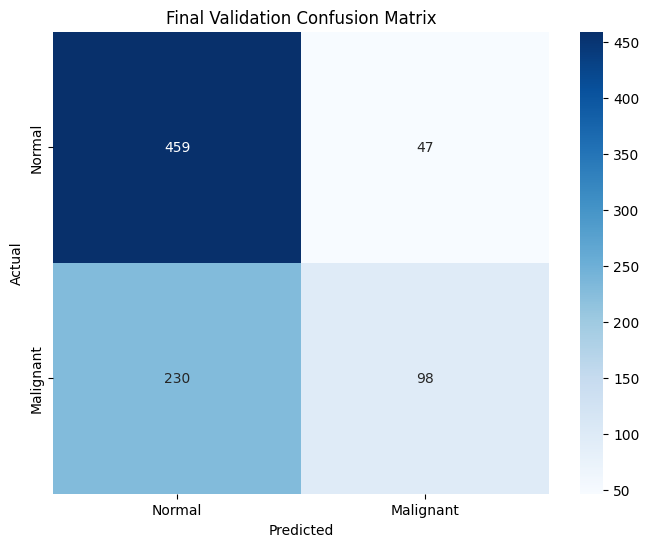


Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.67      0.91      0.77       506
   Malignant       0.68      0.30      0.41       328

    accuracy                           0.67       834
   macro avg       0.67      0.60      0.59       834
weighted avg       0.67      0.67      0.63       834



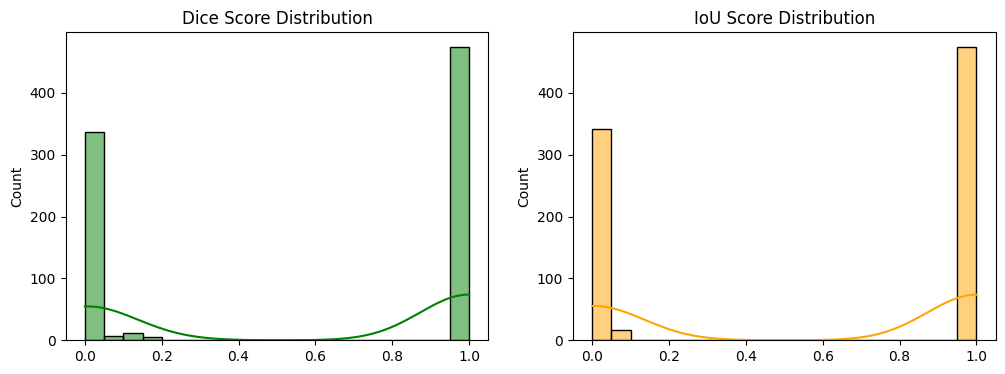

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_cls_true, all_cls_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Malignant'], 
            yticklabels=['Normal', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Validation Confusion Matrix')
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(all_cls_true, all_cls_preds, target_names=['Normal', 'Malignant']))

# 4. Plot Metric Distributions for Segmentation
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(dice_scores, bins=20, kde=True, color='green')
plt.title('Dice Score Distribution')

plt.subplot(1, 2, 2)
sns.histplot(iou_scores, bins=20, kde=True, color='orange')
plt.title('IoU Score Distribution')
plt.show()

In [ ]:
# SEGMENTATION MODEL EVALUATION

dice_scores = []
iou_scores = []
cls_accuracy = []

# Evaluate on validation set
for i in range(0, len(val_images), BATCH_SIZE):
    batch_images = val_images[i:i+BATCH_SIZE]
    batch_masks = val_masks[i:i+BATCH_SIZE]
    batch_cls_labels = y_val_labels[i:i+BATCH_SIZE]
    
    preds = model.predict(batch_images)
    
    mask_preds = preds[0]     # segmentation predictions
    cls_preds = preds[1]      # classification predictions
    
    mask_preds_binary = (mask_preds > 0.5).astype(np.float32)
    cls_preds_binary = (cls_preds > 0.5).astype(np.float32).flatten()
    
    for j in range(len(batch_images)):
        # Segmentation metrics
        y_true = batch_masks[j].flatten()
        y_pred = mask_preds_binary[j].flatten()
        
        intersection = np.sum(y_true * y_pred)
        
        dice = (2 * intersection + 1) / (
            np.sum(y_true) + np.sum(y_pred) + 1
        )
        
        union = np.sum(y_true) + np.sum(y_pred) - intersection
        iou = (intersection + 1) / (union + 1)
        
        dice_scores.append(dice)
        iou_scores.append(iou)
        
        # Classification accuracy
        cls_true = batch_cls_labels[j]
        cls_pred = cls_preds_binary[j]
        accuracy = 1.0 if (cls_pred == cls_true) else 0.0
        cls_accuracy.append(accuracy)

print("\nModel Evaluation Results")
print("-" * 40)
print("Dice Score (Avg):", round(np.mean(dice_scores), 4))
print("IoU Score (Avg):", round(np.mean(iou_scores), 4))
print("Classification Accuracy:", round(np.mean(cls_accuracy), 4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 748ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 768ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 792ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 767ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 816ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 769ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 834ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 787ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 808ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 834ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 801ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 864ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 826ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 841ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 854ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 864ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 873ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 911ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 900ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 844ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [87]:
# SAVE RESULTS

def save_prediction(image_path, save_path="result.png"):

    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    resized = cv2.resize(image_rgb, (IMG_SIZE, IMG_SIZE))
    normalized = resized / 255.0
    input_img = np.expand_dims(normalized, axis=0)

    predictions = segmentation_model.predict(input_img)
    mask_pred = predictions[0]   # segmentation
    cls_pred = predictions[1]    # classification

    mask = mask_pred[0]
    confidence = float(cls_pred[0][0])
    binary_mask = (mask > 0.5).astype(np.uint8).squeeze()

    classes = ["Normal", "Malignant"]
    class_id = int(confidence > 0.5)
    prediction = classes[class_id]

    if prediction == "Normal":

        plt.imshow(image_rgb)
        plt.title(f"{prediction} ({confidence:.2f})")
        plt.axis("off")

        plt.savefig(save_path)
        print("Saved:", save_path)
        return

    overlay, mask_resized = create_overlay(image_rgb, binary_mask)
    bbox = get_bounding_box(mask_resized)
    bbox_img = draw_bounding_box(image_rgb, bbox)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image_rgb)
    plt.title("Original")

    plt.subplot(1, 3, 2)
    plt.imshow(overlay)
    plt.title("Tumor Overlay")

    plt.subplot(1, 3, 3)
    plt.imshow(bbox_img)
    plt.title("Bounding Box")

    plt.savefig(save_path)

    print("Saved:", save_path)